In [10]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.cluster import KMeans



In [7]:
image_path = "../output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

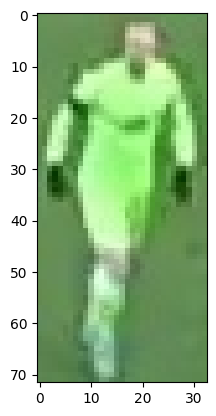

In [8]:
plt.imshow(image)
plt.show()

# Take top half of image 

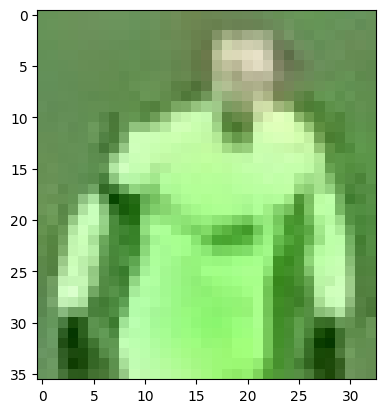

In [9]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)

## Cluster image into two clusters of kit and background


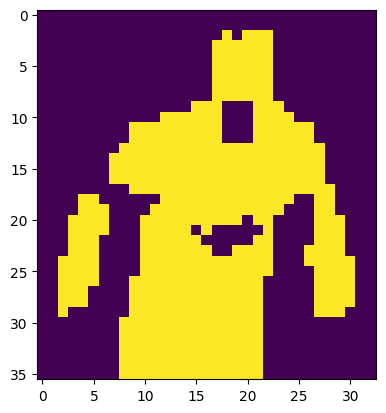

In [17]:
 # reshape image into 2d array 
image_2d = top_half_image.reshape(-1,3)

# KMeans clustering w 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get clusters labels
labels = kmeans.labels_

# reshape labels back to original image shape 
clustered_image = labels.reshape(top_half_image.shape[0],top_half_image.shape[1])

# Display the clustered image 
plt.imshow(clustered_image)
plt.show()



In [13]:
corner_clusters = [clustered_image[0,0],clustered_image[0,-1],clustered_image[-1,0],clustered_image[-1,-1]]
non_player_cluster = max(set(corner_clusters),key=corner_clusters.count)
print(non_player_cluster)

0


In [19]:
edges = np.concatenate([clustered_image[0,:], clustered_image[-1,:], clustered_image[:,0], clustered_image[:,-1]])
most_common_at_edges = np.bincount(edges).argmax()

# If the most common at edges is '0' and you want it to be '1', swap them
if most_common_at_edges == 0:
    non_player_cluster = 1
    player_cluster = 0
else:
    non_player_cluster = 0
    player_cluster = 1

print(player_cluster)
print(non_player_cluster)

0
1


In [14]:
player_cluster = non_player_cluster+1
print(player_cluster)

1


In [15]:
kmeans.cluster_centers_[player_cluster]

array([172.93927126, 237.9534413 , 147.76720648])